# ipynb/loc_compare_nofont.ipynb - 定位对比(无字体) / Localization compare (no font)

## 项目背景 / Background
定位对比(无字体)
Localization compare (no font)

## 功能模块 / Modules
- 无字体版定位对比
- (详见各代码单元 / see code cells)

## 输入 / Inputs
- 上一阶段产物(.npy/.pt/.csv/.json)/ prior-stage outputs
- 内嵌常量与参数 / inline constants and params

## 输出 / Outputs
- 图表(内联显示) / figures (inline)
- 中间变量 / intermediate variables
- 导出文件(.png/.pdf/.csv) / exported files

## 数据流 / Data Flow
1. 加载数据 / Load data
2. 运行分析 / Run analysis
3. 渲染图表 / Render figures
4. 导出 / Export

## 相关文件 / Related Files
- 调用 / Calls: ipynb/loc_compare.ipynb
- 被调用 / Called by: 报告 / 论文 / report / paper

## 使用示例 / Usage Example
- 在 JupyterLab 中打开 / open in JupyterLab
- 逐单元运行 / run cells sequentially

## 作者 / Author
项目组 / Project Team

## 版本 / Version
1.0



Warning message:
"Vectorized input to `element_text()` is not officially supported.
i Results may be unexpected or may change in future versions of ggplot2."


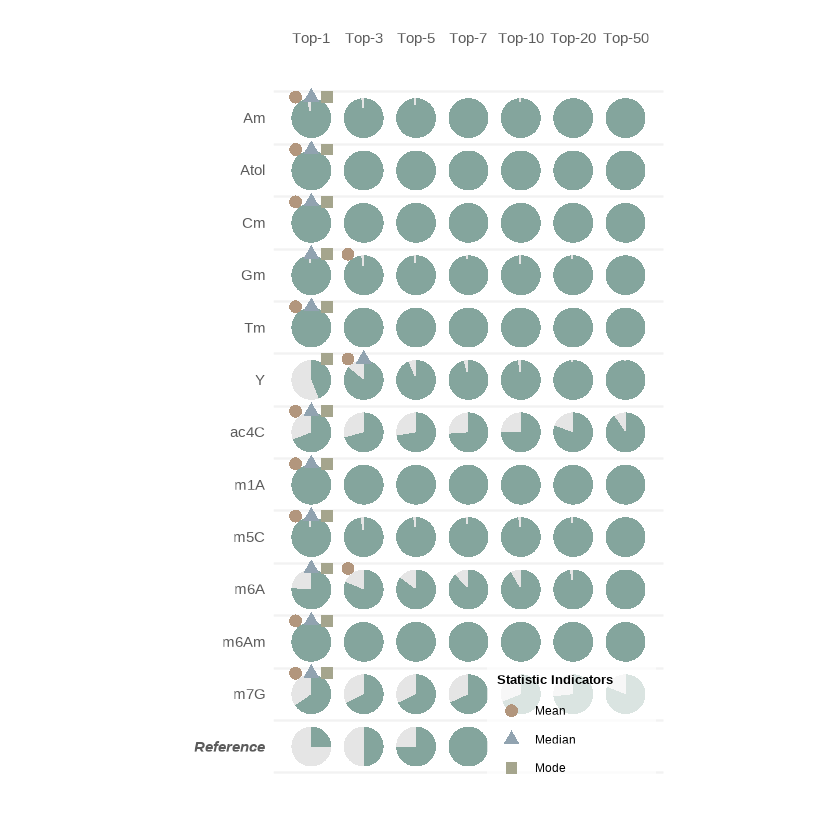

In [5]:
# ==========================================
# 1. 加载必要的库
# ==========================================
library(showtext)
library(ggplot2)
library(dplyr)
library(tidyr)
library(scales)
library(ggforce)  # 核心：用于绘制饼图 geom_arc_bar

# 开启字体支持
showtext_auto()

# ==========================================
# 2. 莫兰迪配色方案定义 (Low Saturation)
# ==========================================
morandi_palette <- list(
  bg_circle   = "#E5E5E5",  # 饼图底色：浅灰
  pie_fill    = "#84A59D",  # 饼图主填充色：莫兰迪绿
  text_dark   = "#5B5B5B",  # 坐标轴文字：深深灰
  grid_line   = "#F2F2F2",  # 水平分割线：极浅灰
  # 统计标识配色
  stat_mean   = "#B2967D",  # Mean: 烟褐色
  stat_median = "#91A3B0",  # Median: 灰蓝色
  stat_mode   = "#A5A58D"   # Mode: 豆沙橄榄绿
)

# ==========================================
# 3. 数据预处理 (包含模拟数据逻辑)
# ==========================================
# 如果您有实际数据，请取消下面两行的注释：
df_loc <- read.csv("data/rgcnformer_loc.csv", check.names = FALSE)
df_stat <- read.csv("data/statistic_loc.csv")

# --- 模拟数据开始 (仅供演示) ---
if(!exists("df_loc")) {
  df_loc <- data.frame(
    Name = c("Class A", "Class B", "Class C", "Class D"),
    "Top-1" = c(0.2, 0.4, 0.6, 0.8), "Top-3" = c(0.3, 0.5, 0.7, 0.9),
    "Top-5" = c(0.4, 0.6, 0.8, 0.95), "Top-7" = c(0.5, 0.7, 0.85, 0.98),
    "Top-10" = c(0.6, 0.8, 0.9, 1.0), "Top-20" = c(0.7, 0.9, 0.95, 1.0),
    "Top-50" = c(0.8, 0.95, 1.0, 1.0), check.names = FALSE
  )
}
if(!exists("df_stat")) {
  df_stat <- data.frame(
    Class = c("Class A", "Class B", "Class C", "Class D"),
    Mean = c(3, 5, 10, 20), Median = c(1, 7, 7, 50), Mode = c(5, 10, 1, 7)
  )
}
# --- 模拟数据结束 ---

# 定义映射逻辑
k_values <- c(1, 3, 5, 7, 10, 20, 50)
k_levels <- c("Top-1", "Top-3", "Top-5", "Top-7", "Top-10", "Top-20", "Top-50")
map_val_to_x <- function(val) {
  idx <- which(k_values >= val)[1]
  if(is.na(idx)) idx <- length(k_values)
  return(idx)
}

# 3.1 处理主饼图数据
classes <- df_loc$Name
class_levels <- rev(classes)

plot_data <- df_loc %>%
  pivot_longer(cols = all_of(k_levels), names_to = "Metric", values_to = "Value") %>%
  mutate(
    Metric_num = as.numeric(factor(Metric, levels = k_levels)),
    Class_num = as.numeric(factor(Name, levels = class_levels)) + 1 # 向上平移，给参考行留位
  )

# 3.2 准备底部的“参考示意图”数据 (Reference Row)
# 展示 25%, 50%, 75%, 100%
ref_data <- data.frame(
  Metric_num = 1:4, 
  Value = c(0.25, 0.50, 0.75, 1.00),
  Class_num = 1, # 放置在第一行
  Name = "Reference"
)

# 合并所有饼图数据
final_plot_data <- bind_rows(plot_data, ref_data)

# 3.3 处理统计标识点
stat_config <- data.frame(
  StatType = c("Mean", "Median", "Mode"),
  Shape = c(16, 17, 15), 
  Color = c(morandi_palette$stat_mean, morandi_palette$stat_median, morandi_palette$stat_mode)
)

df_markers <- df_stat %>%
  rename(Name = Class) %>%
  select(Name, Mean, Median, Mode) %>%
  pivot_longer(cols = -Name, names_to = "StatType", values_to = "Value") %>%
  mutate(
    Class_num = as.numeric(factor(Name, levels = class_levels)) + 1,
    Base_X = sapply(Value, map_val_to_x)
  ) %>%
  left_join(stat_config, by = "StatType") %>%
  mutate(
    X_pos = Base_X + c(-0.3, 0, 0.3)[match(StatType, c("Mean", "Median", "Mode"))],
    Y_pos = Class_num + 0.4 
  )

# ==========================================
# 4. 开始绘图
# ==========================================
y_labels <- c("Reference", class_levels)

p <- ggplot() +
  # A. 背景水平分割线 (取消竖线)
  geom_hline(yintercept = seq(0.5, length(y_labels) + 0.5, 1), 
             color = morandi_palette$grid_line, size = 0.5) +
  
  # B. 绘制实心饼图底色 (r0 = 0 代表实心)
  geom_arc_bar(data = final_plot_data,
               aes(x0 = Metric_num, y0 = Class_num, r0 = 0, r = 0.38, 
                   start = 0, end = 2*pi),
               fill = morandi_palette$bg_circle, color = NA) +
  
  # C. 绘制进度饼图 (莫兰迪绿填充)
  geom_arc_bar(data = final_plot_data,
               aes(x0 = Metric_num, y0 = Class_num, r0 = 0, r = 0.38, 
                   start = 0, end = Value * 2 * pi),
               fill = morandi_palette$pie_fill, color = NA) +
  
  # D. 绘制统计标识点
  geom_point(data = df_markers,
             aes(x = X_pos, y = Y_pos, color = StatType, shape = StatType),
             size = 3) +
  
  # E. 坐标轴与比例尺
  coord_fixed(ratio = 1) +
  scale_x_continuous(breaks = 1:length(k_levels), labels = k_levels, position = "top") +
  scale_y_continuous(breaks = 1:length(y_labels), labels = y_labels) +
  
  # F. 图例设置 (手动设置颜色与形状)
  scale_color_manual(name = "Statistic Indicators", 
                     values = setNames(stat_config$Color, stat_config$StatType)) +
  scale_shape_manual(name = "Statistic Indicators", 
                     values = setNames(stat_config$Shape, stat_config$StatType)) +
  
  # G. 极致精简的主题
  theme_minimal() +
  theme(
    axis.title = element_blank(),
    axis.text = element_text(size = 11, color = morandi_palette$text_dark),
    # 突出 Reference 字样
    axis.text.y = element_text(face = ifelse(y_labels == "Reference", "bold.italic", "plain")),
    panel.grid = element_blank(),
    
    # 图例：右下角竖排
    legend.position = c(0.98, 0.02),
    legend.justification = c("right", "bottom"),
    legend.direction = "vertical",
    legend.background = element_rect(fill = alpha("white", 0.7), color = NA),
    legend.title = element_text(size = 10, face = "bold"),
    legend.key = element_blank(),
    
    plot.margin = margin(20, 20, 20, 20)
  )

# ==========================================
# 5. 保存图表
# ==========================================
# 使用 cairo_pdf 确保莫兰迪色的颜色还原度
ggsave("localization_morandi_final.pdf", p, width = 11, height = 11, device = cairo_pdf)

# 打印预览
print(p)

Warning message:
"Vectorized input to `element_text()` is not officially supported.
i Results may be unexpected or may change in future versions of ggplot2."


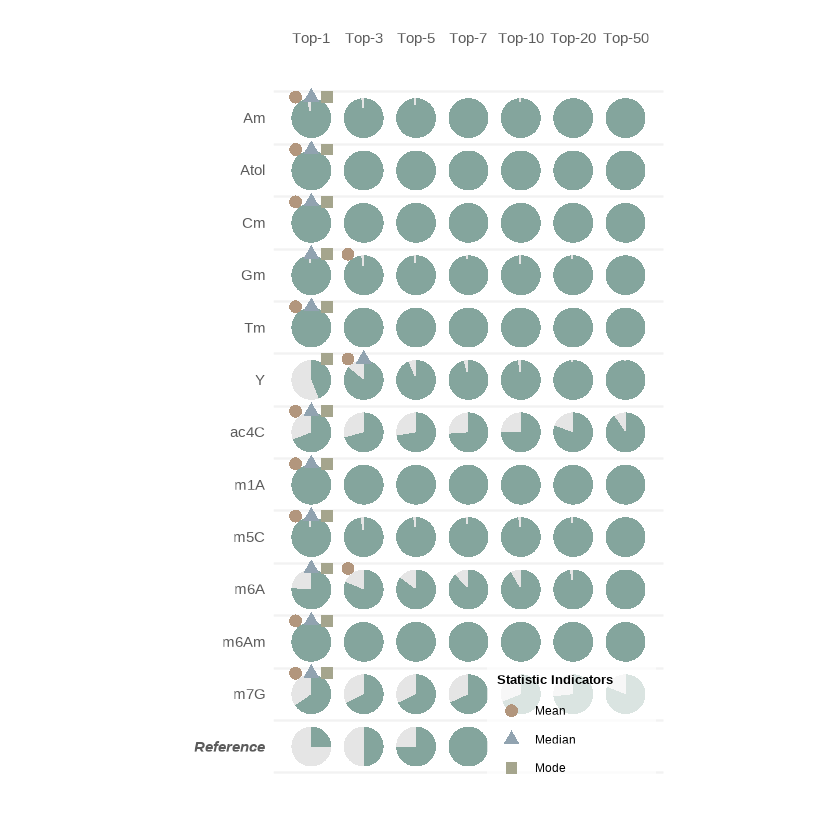

In [ ]:
# ==========================================
# 1. 加载必要的库
# ==========================================
library(showtext)
library(ggplot2)
library(dplyr)
library(tidyr)
library(scales)
library(ggforce)  # 核心：用于绘制饼图 geom_arc_bar

# 开启字体支持
showtext_auto()

# ==========================================
# 2. 莫兰迪配色方案定义 (Low Saturation)
# ==========================================
morandi_palette <- list(
  bg_circle   = "#E5E5E5",  # 饼图底色：浅灰
  pie_fill    = "#84A59D",  # 饼图主填充色：莫兰迪绿
  text_dark   = "#5B5B5B",  # 坐标轴文字：深深灰
  grid_line   = "#F2F2F2",  # 水平分割线：极浅灰
  # 统计标识配色
  stat_mean   = "#B2967D",  # Mean: 烟褐色
  stat_median = "#91A3B0",  # Median: 灰蓝色
  stat_mode   = "#A5A58D"   # Mode: 豆沙橄榄绿
)

# ==========================================
# 3. 数据预处理 (包含模拟数据逻辑)
# ==========================================
# 如果您有实际数据，请取消下面两行的注释：
df_loc <- read.csv("data/rgcnformer_loc.csv", check.names = FALSE)
df_stat <- read.csv("data/statistic_loc.csv")

# --- 模拟数据开始 (仅供演示) ---
if(!exists("df_loc")) {
  df_loc <- data.frame(
    Name = c("Class A", "Class B", "Class C", "Class D"),
    "Top-1" = c(0.2, 0.4, 0.6, 0.8), "Top-3" = c(0.3, 0.5, 0.7, 0.9),
    "Top-5" = c(0.4, 0.6, 0.8, 0.95), "Top-7" = c(0.5, 0.7, 0.85, 0.98),
    "Top-10" = c(0.6, 0.8, 0.9, 1.0), "Top-20" = c(0.7, 0.9, 0.95, 1.0),
    "Top-50" = c(0.8, 0.95, 1.0, 1.0), check.names = FALSE
  )
}
if(!exists("df_stat")) {
  df_stat <- data.frame(
    Class = c("Class A", "Class B", "Class C", "Class D"),
    Mean = c(3, 5, 10, 20), Median = c(1, 7, 7, 50), Mode = c(5, 10, 1, 7)
  )
}
# --- 模拟数据结束 ---

# 定义映射逻辑
k_values <- c(1, 3, 5, 7, 10, 20, 50)
k_levels <- c("Top-1", "Top-3", "Top-5", "Top-7", "Top-10", "Top-20", "Top-50")
map_val_to_x <- function(val) {
  idx <- which(k_values >= val)[1]
  if(is.na(idx)) idx <- length(k_values)
  return(idx)
}

# 3.1 处理主饼图数据
classes <- df_loc$Name
class_levels <- rev(classes)

plot_data <- df_loc %>%
  pivot_longer(cols = all_of(k_levels), names_to = "Metric", values_to = "Value") %>%
  mutate(
    Metric_num = as.numeric(factor(Metric, levels = k_levels)),
    Class_num = as.numeric(factor(Name, levels = class_levels)) + 1 # 向上平移，给参考行留位
  )

# 3.2 准备底部的“参考示意图”数据 (Reference Row)
# 展示 25%, 50%, 75%, 100%
ref_data <- data.frame(
  Metric_num = 1:4, 
  Value = c(0.25, 0.50, 0.75, 1.00),
  Class_num = 1, # 放置在第一行
  Name = "Reference"
)

# 合并所有饼图数据
final_plot_data <- bind_rows(plot_data, ref_data)

# 3.3 处理统计标识点
stat_config <- data.frame(
  StatType = c("Mean", "Median", "Mode"),
  Shape = c(16, 17, 15), 
  Color = c(morandi_palette$stat_mean, morandi_palette$stat_median, morandi_palette$stat_mode)
)

df_markers <- df_stat %>%
  rename(Name = Class) %>%
  select(Name, Mean, Median, Mode) %>%
  pivot_longer(cols = -Name, names_to = "StatType", values_to = "Value") %>%
  mutate(
    Class_num = as.numeric(factor(Name, levels = class_levels)) + 1,
    Base_X = sapply(Value, map_val_to_x)
  ) %>%
  left_join(stat_config, by = "StatType") %>%
  mutate(
    X_pos = Base_X + c(-0.3, 0, 0.3)[match(StatType, c("Mean", "Median", "Mode"))],
    Y_pos = Class_num + 0.4 
  )

# ==========================================
# 4. 开始绘图
# ==========================================
y_labels <- c("Reference", class_levels)

p <- ggplot() +
  # A. 背景水平分割线 (取消竖线)
  geom_hline(yintercept = seq(0.5, length(y_labels) + 0.5, 1), 
             color = morandi_palette$grid_line, size = 0.5) +
  
  # B. 绘制实心饼图底色 (r0 = 0 代表实心)
  geom_arc_bar(data = final_plot_data,
               aes(x0 = Metric_num, y0 = Class_num, r0 = 0, r = 0.38, 
                   start = 0, end = 2*pi),
               fill = morandi_palette$bg_circle, color = NA) +
  
  # C. 绘制进度饼图 (莫兰迪绿填充)
  geom_arc_bar(data = final_plot_data,
               aes(x0 = Metric_num, y0 = Class_num, r0 = 0, r = 0.38, 
                   start = 0, end = Value * 2 * pi),
               fill = morandi_palette$pie_fill, color = NA) +
  
  # D. 绘制统计标识点
  geom_point(data = df_markers,
             aes(x = X_pos, y = Y_pos, color = StatType, shape = StatType),
             size = 3) +
  
  # E. 坐标轴与比例尺
  coord_fixed(ratio = 1) +
  scale_x_continuous(breaks = 1:length(k_levels), labels = k_levels, position = "top") +
  scale_y_continuous(breaks = 1:length(y_labels), labels = y_labels) +
  
  # F. 图例设置 (手动设置颜色与形状)
  scale_color_manual(name = "Statistic Indicators", 
                     values = setNames(stat_config$Color, stat_config$StatType)) +
  scale_shape_manual(name = "Statistic Indicators", 
                     values = setNames(stat_config$Shape, stat_config$StatType)) +
  
  # G. 极致精简的主题
  theme_minimal() +
  theme(
    axis.title = element_blank(),
    axis.text = element_text(size = 11, color = morandi_palette$text_dark),
    # 突出 Reference 字样
    axis.text.y = element_text(face = ifelse(y_labels == "Reference", "bold.italic", "plain")),
    panel.grid = element_blank(),
    
    # 图例：右下角竖排
    legend.position = c(0.98, 0.02),
    legend.justification = c("right", "bottom"),
    legend.direction = "vertical",
    legend.background = element_rect(fill = alpha("white", 0.7), color = NA),
    legend.title = element_text(size = 10, face = "bold"),
    legend.key = element_blank(),
    
    plot.margin = margin(20, 20, 20, 20)
  )

# ==========================================
# 5. 保存图表
# ==========================================
# 使用 cairo_pdf 确保莫兰迪色的颜色还原度
ggsave("localization_morandi_final.pdf", p, width = 11, height = 11, device = cairo_pdf)

# 打印预览
print(p)

Warning message in geom_arc_bar(data = plot_data, aes(x0 = Metric_num, y0 = Class_num, :
"Ignoring unknown parameters: `linejoin`"
Warning message in geom_arc_bar(data = ref_df, aes(x0 = x, y0 = y, r0 = 0, r = r_inner, :
"Ignoring unknown parameters: `linejoin`"


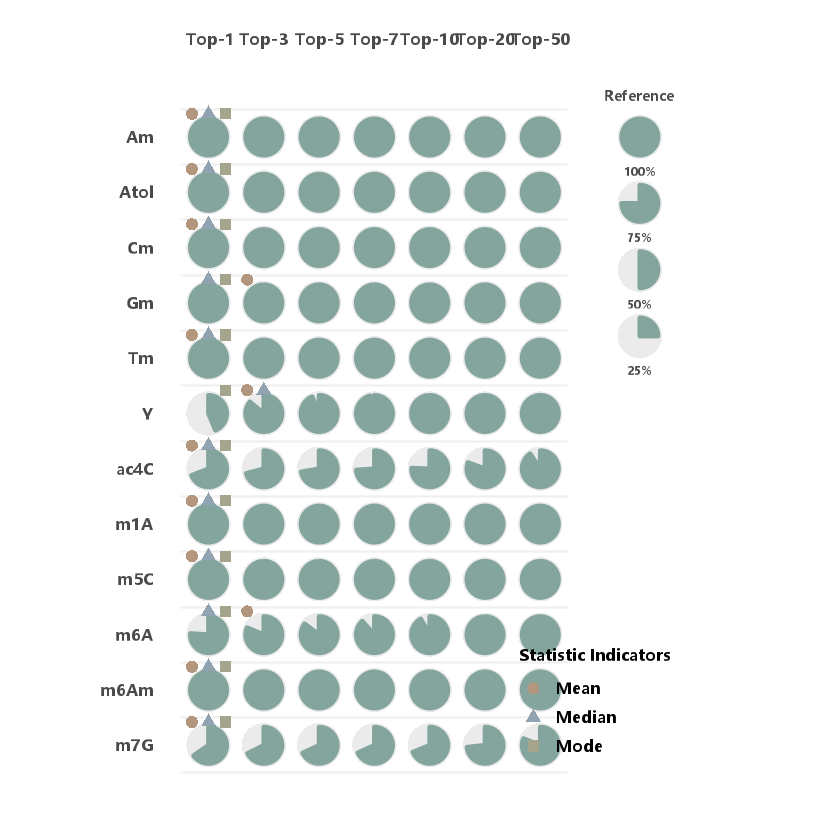

In [14]:
# ==========================================
# 1. 环境配置与字体加载
# ==========================================
library(showtext)
library(ggplot2)
library(dplyr)
library(tidyr)
library(ggforce)

# 使用你提供的 WSL 绝对路径加载微软雅黑
# regular 为常规体，bold 为粗体
font_add("Microsoft YaHei", 
         regular = "/mnt/c/Windows/Fonts/msyh.ttc", 
         bold = "/mnt/c/Windows/Fonts/msyhbd.ttc")
showtext_auto()

# ==========================================
# 2. 全局参数设置 (一键管理)
# ==========================================
unified_radius <- 0.40     # 所有饼图的统一半径
gap_ratio      <- 0.82     # 内部进度相对于底圆的比例
ref_spacing    <- 1.2      # Reference 示意图内部的垂直间距
font_size      <- 12       # 轴文字大小
font_family    <- "Microsoft YaHei"

r_outer <- unified_radius
r_inner <- unified_radius * gap_ratio

# 莫兰迪配色方案
morandi_palette <- list(
  bg_circle   = "#EBEBEB",  # 饼图底色
  pie_fill    = "#84A59D",  # 饼图填充色
  text_dark   = "#4A4A4A",  # 文字颜色
  grid_line   = "#F0F0F0",  # 水平分割线
  stat_mean   = "#B2967D",  # 均值点颜色
  stat_median = "#91A3B0",  # 中位数点颜色
  stat_mode   = "#A5A58D"   # 众数点颜色
)

# ==========================================
# 3. 数据加载与预处理 (健壮性处理)
# ==========================================

# A. 加载主数据 (若文件缺失则生成模拟数据)
if(file.exists("data/rgcnformer_loc.csv")) {
  df_loc <- read.csv("data/rgcnformer_loc.csv", check.names = FALSE)
} else {
  df_loc <- data.frame(
    Name = paste("Category", LETTERS[1:8]),
    "Top-1" = runif(8, 0.1, 0.4), "Top-3" = runif(8, 0.3, 0.6),
    "Top-5" = runif(8, 0.4, 0.7), "Top-7" = runif(8, 0.5, 0.8),
    "Top-10" = runif(8, 0.6, 0.9), "Top-20" = runif(8, 0.7, 0.95),
    "Top-50" = runif(8, 0.8, 1.0), check.names = FALSE
  )
}

if(file.exists("data/statistic_loc.csv")) {
  df_stat <- read.csv("data/statistic_loc.csv")
} else {
  df_stat <- data.frame(
    Class = df_loc$Name,
    Mean = sample(1:50, 8), Median = sample(1:50, 8), Mode = sample(1:50, 8)
  )
}

# B. 定义映射与层级
k_values <- c(1, 3, 5, 7, 10, 20, 50)
k_levels <- c("Top-1", "Top-3", "Top-5", "Top-7", "Top-10", "Top-20", "Top-50")
class_levels <- rev(df_loc$Name)
n_classes <- length(class_levels)
n_k <- length(k_levels)

# 处理绘图长表
plot_data <- df_loc %>%
  pivot_longer(cols = all_of(k_levels), names_to = "Metric", values_to = "Value") %>%
  mutate(
    Metric_num = as.numeric(factor(Metric, levels = k_levels)),
    Class_num = as.numeric(factor(Name, levels = class_levels))
  )

# C. 处理统计标识点
stat_config <- data.frame(
  StatType = c("Mean", "Median", "Mode"),
  Shape = c(16, 17, 15), 
  Color = c(morandi_palette$stat_mean, morandi_palette$stat_median, morandi_palette$stat_mode)
)

map_val_to_x <- function(val) {
  idx <- which(k_values >= val)[1]
  if(is.na(idx)) idx <- length(k_values)
  return(idx)
}

df_markers <- df_stat %>%
  rename(Name = 1) %>%
  pivot_longer(cols = c(Mean, Median, Mode), names_to = "StatType", values_to = "Value") %>%
  mutate(
    Class_num = as.numeric(factor(Name, levels = class_levels)),
    Base_X = sapply(Value, map_val_to_x)
  ) %>%
  left_join(stat_config, by = "StatType") %>%
  mutate(
    X_pos = Base_X + c(-0.3, 0, 0.3)[match(StatType, c("Mean", "Median", "Mode"))],
    Y_pos = Class_num + 0.42
  )

# D. 建立 Reference 专用坐标 (在主图 X 轴外)
ref_x_pos <- n_k + 1.8
ref_df <- data.frame(
  x = ref_x_pos,
  y = seq(from = n_classes, by = -ref_spacing, length.out = 4), 
  val = c(1.00, 0.75, 0.50, 0.25),
  label = c("100%", "75%", "50%", "25%")
)

# ==========================================
# 4. 核心绘图逻辑
# ==========================================


p <- ggplot() +
  # A. 水平分割线 (限定宽度，不影响侧边 Reference)
  annotate("segment", 
           x = 0.5, xend = n_k + 0.5, 
           y = seq(0.5, n_classes + 0.5, 1), 
           yend = seq(0.5, n_classes + 0.5, 1),
           color = morandi_palette$grid_line, linewidth = 0.5) +
  
  # B. 主图：实心饼图绘制 (应用统一半径与圆角)
  geom_arc_bar(data = plot_data,
               aes(x0 = Metric_num, y0 = Class_num, r0 = 0, r = r_outer, start = 0, end = 2*pi),
               fill = morandi_palette$bg_circle, color = NA) +
  geom_arc_bar(data = plot_data,
               aes(x0 = Metric_num, y0 = Class_num, r0 = 0, r = r_inner, start = 0, end = Value * 2 * pi),
               fill = morandi_palette$pie_fill, color = morandi_palette$pie_fill,
               linewidth = 1, linejoin = "round") +
  
  # C. 统计标识点绘制
  geom_point(data = df_markers,
             aes(x = X_pos, y = Y_pos, color = StatType, shape = StatType),
             size = 2.8) +
  
  # D. Reference 组件 (利用 clip="off" 渲染在右侧页边距)
  annotate("text", x = ref_x_pos, y = max(ref_df$y) + 0.75, label = "Reference", 
           size = font_size/3.2, fontface = "bold", family = font_family, color = morandi_palette$text_dark) +
  geom_arc_bar(data = ref_df,
               aes(x0 = x, y0 = y, r0 = 0, r = r_outer, start = 0, end = 2*pi),
               fill = morandi_palette$bg_circle, color = NA) +
  geom_arc_bar(data = ref_df,
               aes(x0 = x, y0 = y, r0 = 0, r = r_inner, start = 0, end = val * 2 * pi),
               fill = morandi_palette$pie_fill, color = morandi_palette$pie_fill,
               linewidth = 1, linejoin = "round") +
  # 标签：置于每个 Reference 饼图正下方
  geom_text(data = ref_df, 
            aes(x = x, y = y - (r_outer + 0.22), label = label),
            size = font_size/3.8, fontface = "bold", family = font_family, color = morandi_palette$text_dark) +
  
  # E. 坐标系控制
  # xlim 限制网格区，clip = "off" 让边距外的组件显示
  coord_fixed(ratio = 1, xlim = c(0.5, n_k + 0.5), clip = "off") +
  scale_x_continuous(breaks = 1:n_k, labels = k_levels, position = "top") +
  scale_y_continuous(breaks = 1:n_classes, labels = class_levels) +
  
  scale_color_manual(name = "Statistic Indicators", values = setNames(stat_config$Color, stat_config$StatType)) +
  scale_shape_manual(name = "Statistic Indicators", values = setNames(stat_config$Shape, stat_config$StatType)) +
  
  # F. 主题设置
  theme_minimal() +
  theme(
    text = element_text(family = font_family),
    axis.title = element_blank(),
    axis.text = element_text(size = font_size, face = "bold", color = morandi_palette$text_dark),
    panel.grid = element_blank(),
    
    # 统计图例：放在侧边空白处，不干扰主图
    legend.position = c(1.3, 0.05), 
    legend.justification = c("right", "bottom"),
    legend.direction = "vertical",
    legend.title = element_text(size = font_size, face = "bold"),
    legend.text = element_text(size = font_size, face = "bold"),
    
    # 给右侧留出 120 像素的空间放置两个“虚拟”图例
    plot.margin = margin(20, 120, 20, 20) 
  )

# ==========================================
# 5. 保存图表
# ==========================================
ggsave("localization_final_standard.pdf", p, width = 14, height = 11, device = cairo_pdf)
print(p)